# Climate Impact Analysis

This notebook performs analytical analysis on the integrated environmental dataset for Delhi.

The dataset combines hourly weather and air-quality observations for 2025.

### Objectives

- Analyze relationships between weather and air pollution
- Examine seasonal and monthly environmental patterns
- Identify extreme pollution and weather events
- Analyze pollutant correlations
- Investigate the relationship between temperature, humidity, rainfall, wind and pollutants
- Engineer analytical features for the dashboard
- Develop a transparent Climate & Environmental Impact Index

> Note: The Climate & Environmental Impact Index developed in this project is an analytical composite indicator for dashboard visualization. It is not an official AQI or government health classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
data_path = Path(
    "../data/processed/environmental_dataset.csv"
)

df = pd.read_csv(data_path)

df["time"] = pd.to_datetime(df["time"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (8760, 21)


,time,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_gusts_10m,year,month,day,hour,day_of_year,season,rain_flag,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2025-01-01 00:00:00,8.3,100,7.4,0.0,99,2.8,4.7,2025,1,1,0,1,Winter,0,185.8,188.6,1645.0,56.7,49.7,31.0
1,2025-01-01 01:00:00,8.0,100,7.0,0.0,100,2.9,5.4,2025,1,1,1,1,Winter,0,174.6,177.4,1551.0,44.8,39.7,39.0
2,2025-01-01 02:00:00,7.8,100,6.5,0.0,100,4.7,10.1,2025,1,1,2,1,Winter,0,164.4,166.7,1478.0,34.6,31.5,46.0
3,2025-01-01 03:00:00,8.0,99,6.5,0.0,100,5.8,12.6,2025,1,1,3,1,Winter,0,156.5,158.8,1418.0,26.7,26.0,52.0
4,2025-01-01 04:00:00,7.7,98,6.1,0.0,100,6.3,13.0,2025,1,1,4,1,Winter,0,149.5,151.8,1379.0,20.6,22.3,57.0


In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["time"].duplicated().sum())

Rows: 8760
Columns: 21
Missing values: 0
Duplicate rows: 0
Duplicate timestamps: 0


In [4]:
weather_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "apparent_temperature",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m"
]

pollutants = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

In [5]:
df[weather_features + pollutants].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,8760.0,25.275342,7.463091,7.7,20.0,26.6,30.500,43.7
relative_humidity_2m,8760.0,60.617922,23.657999,4.0,42.0,63.0,80.000,100.0
apparent_temperature,8760.0,26.892831,9.271445,5.8,19.1,28.9,34.500,46.6
precipitation,8760.0,0.081735,0.530325,0.0,0.0,0.0,0.000,12.0
cloud_cover,8760.0,34.272717,41.845766,0.0,0.0,7.0,88.000,100.0
wind_speed_10m,8760.0,6.640685,3.417600,0.0,4.2,6.1,8.600,25.8
wind_gusts_10m,8760.0,17.578573,8.730237,0.7,11.2,16.2,23.000,71.6
pm2_5,8760.0,80.291941,45.879492,6.0,49.4,70.5,98.300,369.7
pm10,8760.0,199.150742,180.054789,6.1,78.0,136.9,251.725,1438.0
carbon_monoxide,8760.0,864.171575,578.033806,176.0,479.0,675.0,1071.000,6889.0


In [6]:
monthly_pollution = (
    df.groupby("month")[pollutants]
      .mean()
)

monthly_pollution

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
month,,,,,,
1,124.460215,127.734005,1514.927419,45.641398,45.262231,78.182796
2,68.833631,106.143304,832.418155,31.801637,29.522173,81.450893
3,77.246505,369.088978,663.653226,25.494489,23.750000,99.846774
4,71.291667,346.311111,635.609722,20.507083,22.908472,130.840278
5,83.255914,365.929839,615.526882,24.011022,24.263710,132.111559
6,74.749861,276.260833,586.206944,25.693056,24.901944,122.069444
7,58.230780,107.894086,671.868280,36.081989,28.069355,96.125000
8,63.130511,179.939651,716.197581,34.772581,24.100672,79.884409
9,42.026667,92.112639,557.075000,28.542639,21.778194,84.283333


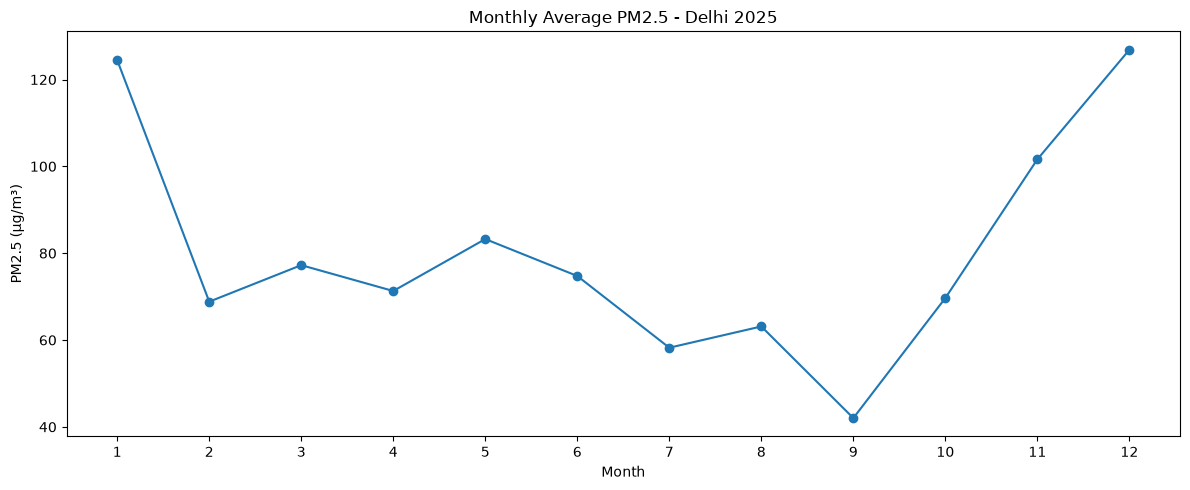

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_pollution.index,
    monthly_pollution["pm2_5"],
    marker="o"
)

plt.title("Monthly Average PM2.5 - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

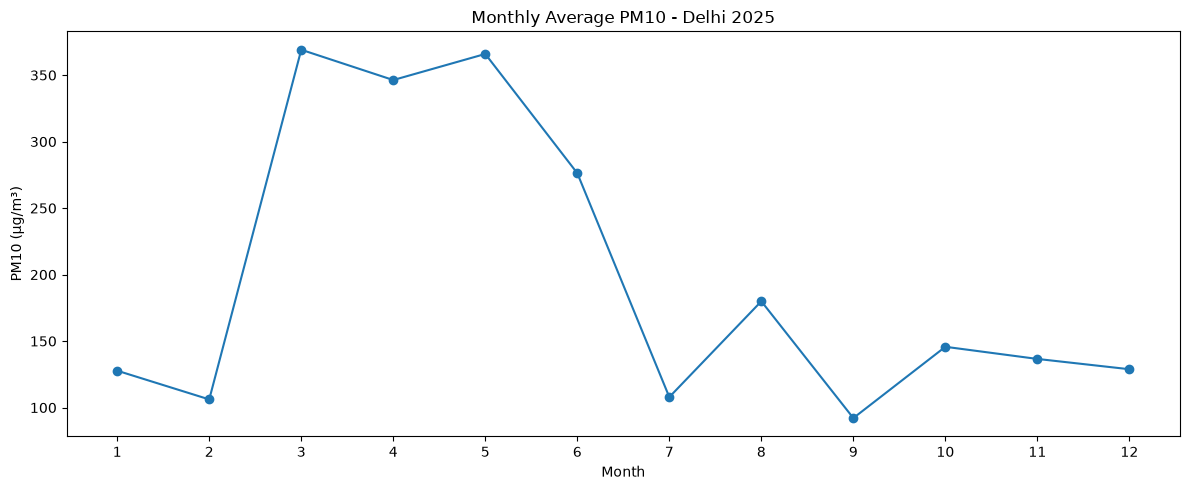

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_pollution.index,
    monthly_pollution["pm10"],
    marker="o"
)

plt.title("Monthly Average PM10 - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("PM10 (µg/m³)")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

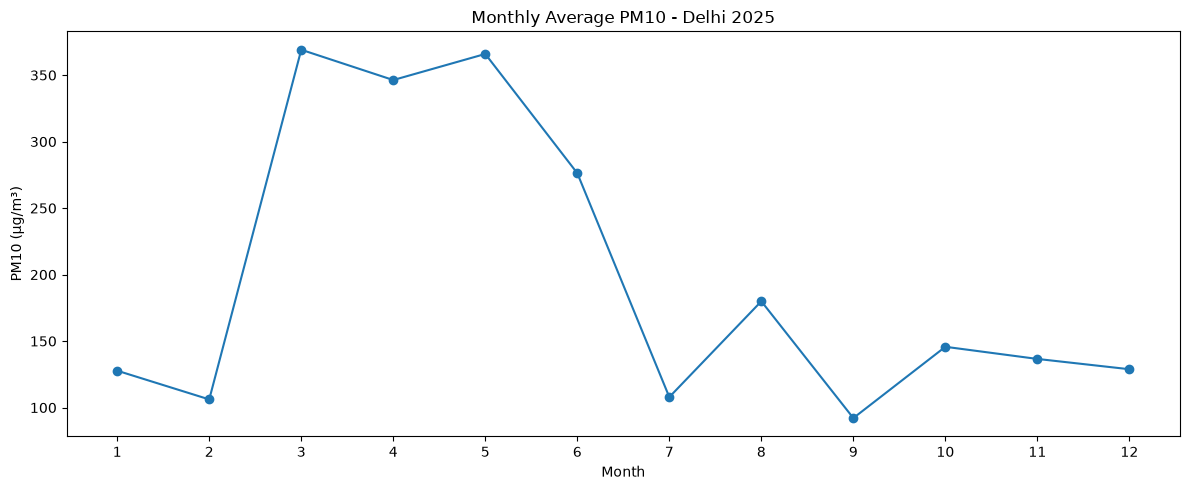

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_pollution.index,
    monthly_pollution["pm10"],
    marker="o"
)

plt.title("Monthly Average PM10 - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("PM10 (µg/m³)")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [10]:
seasonal_pollution = (
    df.groupby("season")[pollutants]
      .mean()
)

seasonal_pollution

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
season,,,,,,
Monsoon,59.553245,163.721721,633.840164,31.340676,24.735041,95.466189
Post-Monsoon,85.387842,141.229235,1044.867486,43.764276,35.364071,87.849044
Summer,77.329620,360.596920,638.292120,23.368297,23.648687,120.825181
Winter,107.978657,121.400787,1284.825926,41.194907,42.540046,83.200000


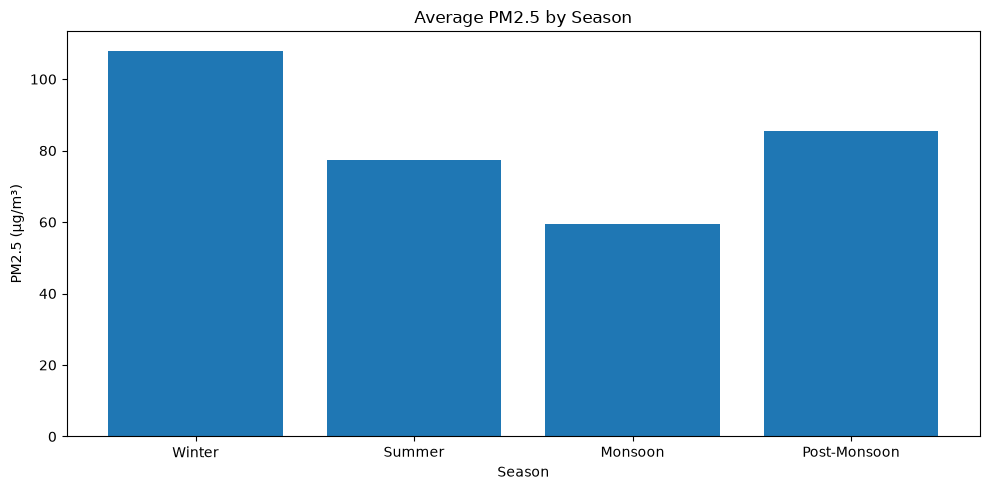

In [11]:
season_order = [
    "Winter",
    "Summer",
    "Monsoon",
    "Post-Monsoon"
]

seasonal_pm25 = (
    df.groupby("season")["pm2_5"]
      .mean()
      .reindex(season_order)
)

plt.figure(figsize=(10, 5))

plt.bar(
    seasonal_pm25.index,
    seasonal_pm25.values
)

plt.title("Average PM2.5 by Season")
plt.xlabel("Season")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

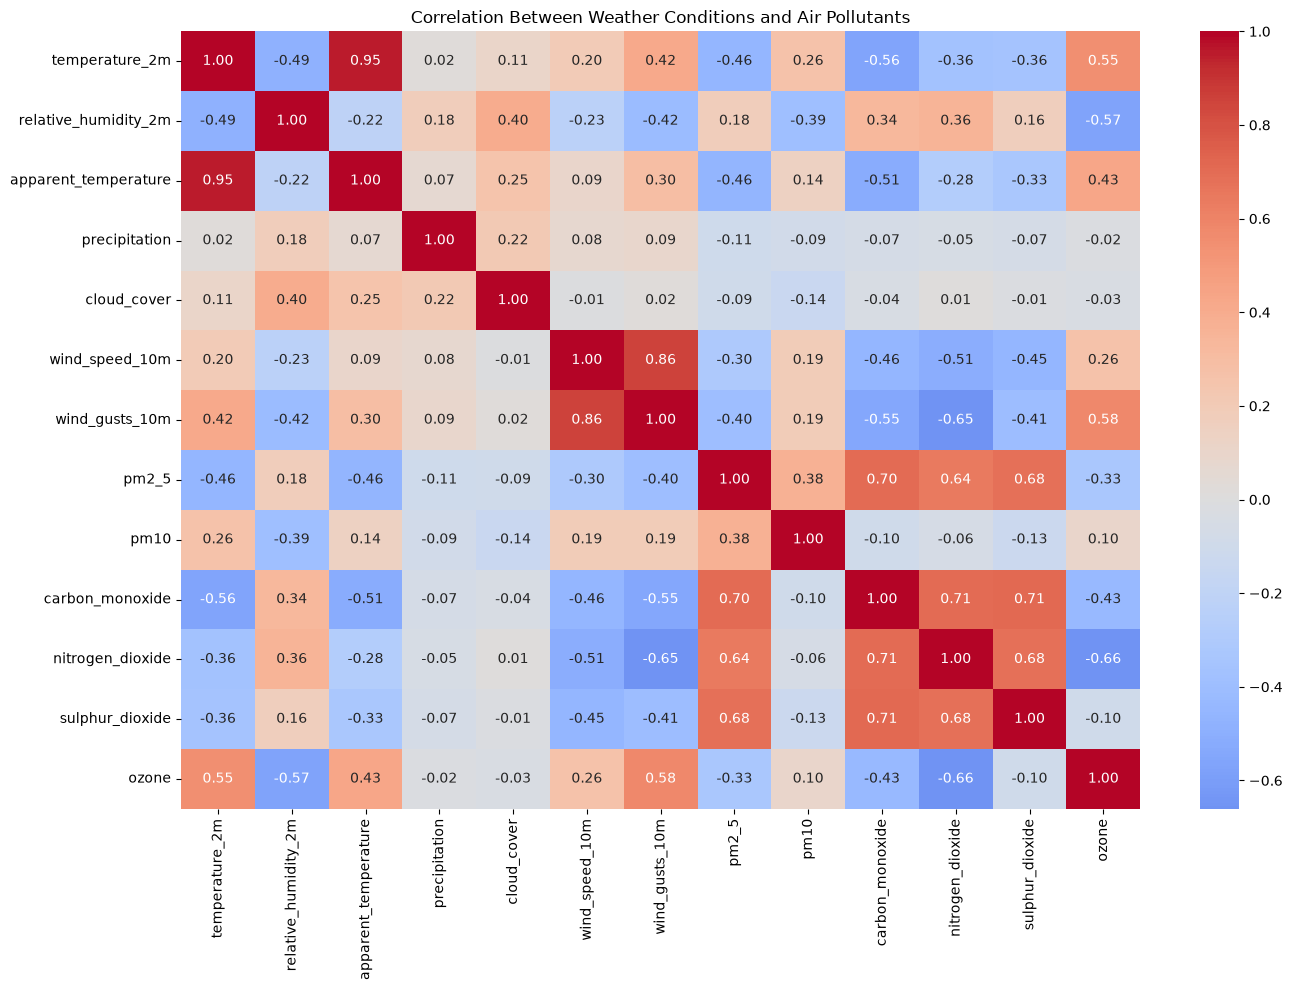

In [12]:
weather_pollution_corr = df[
    weather_features + pollutants
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    weather_pollution_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Weather Conditions and Air Pollutants"
)

plt.tight_layout()
plt.show()

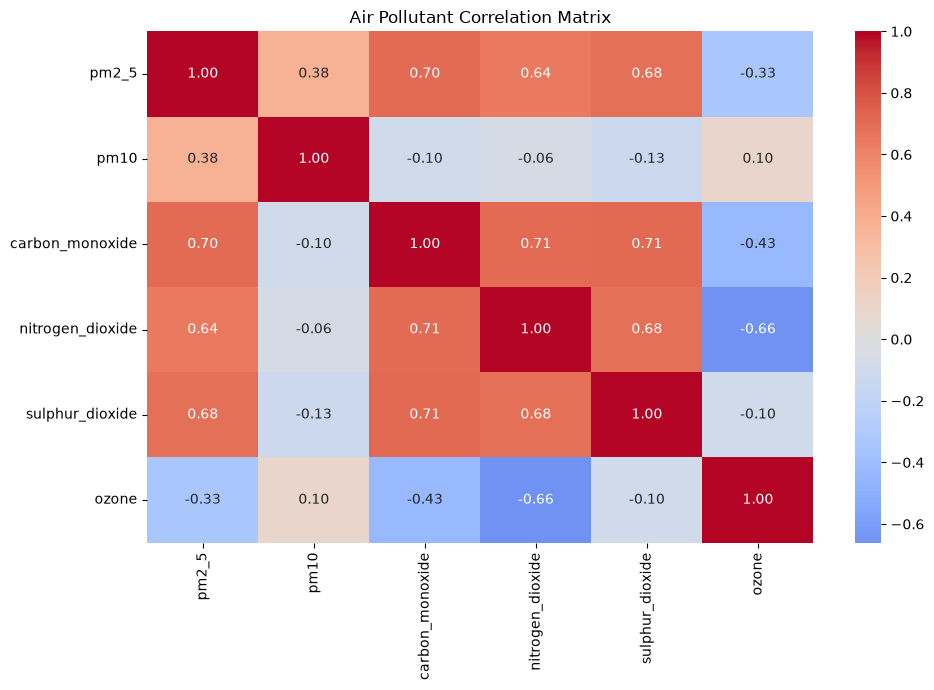

In [13]:
pollution_corr = df[pollutants].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    pollution_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Air Pollutant Correlation Matrix")

plt.tight_layout()
plt.show()

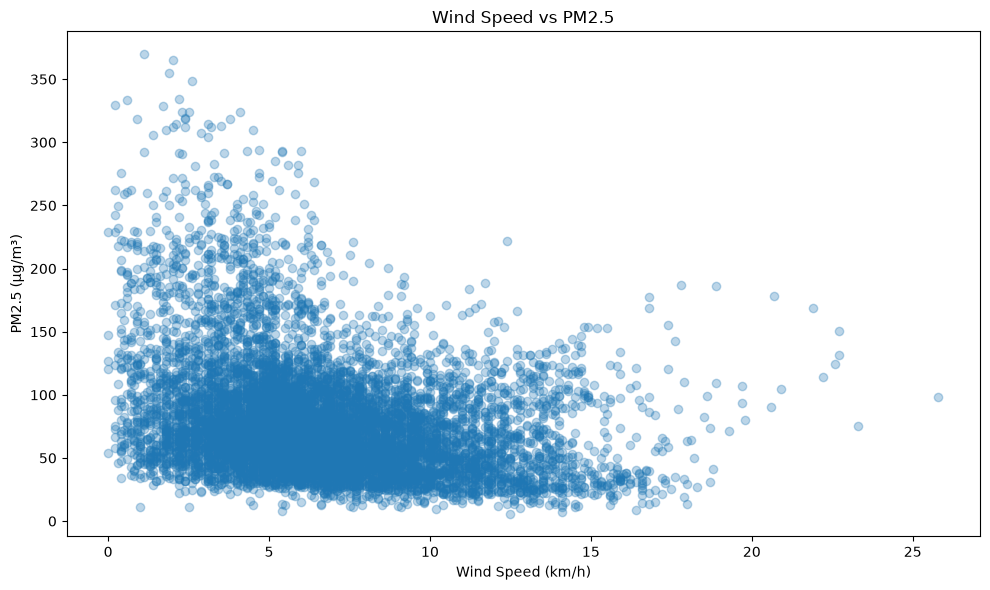

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["wind_speed_10m"],
    df["pm2_5"],
    alpha=0.3
)

plt.title("Wind Speed vs PM2.5")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

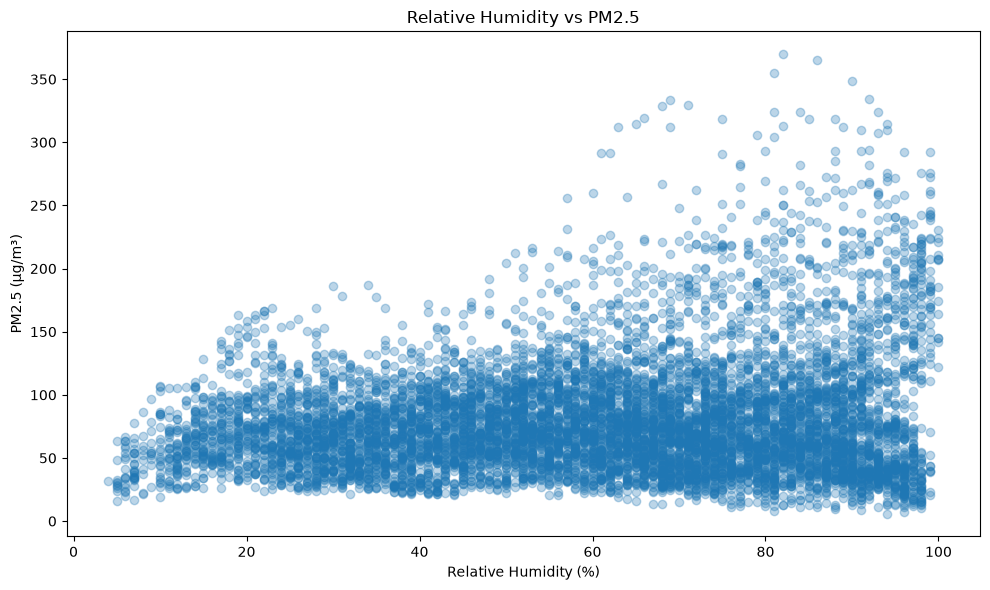

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["relative_humidity_2m"],
    df["pm2_5"],
    alpha=0.3
)

plt.title("Relative Humidity vs PM2.5")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

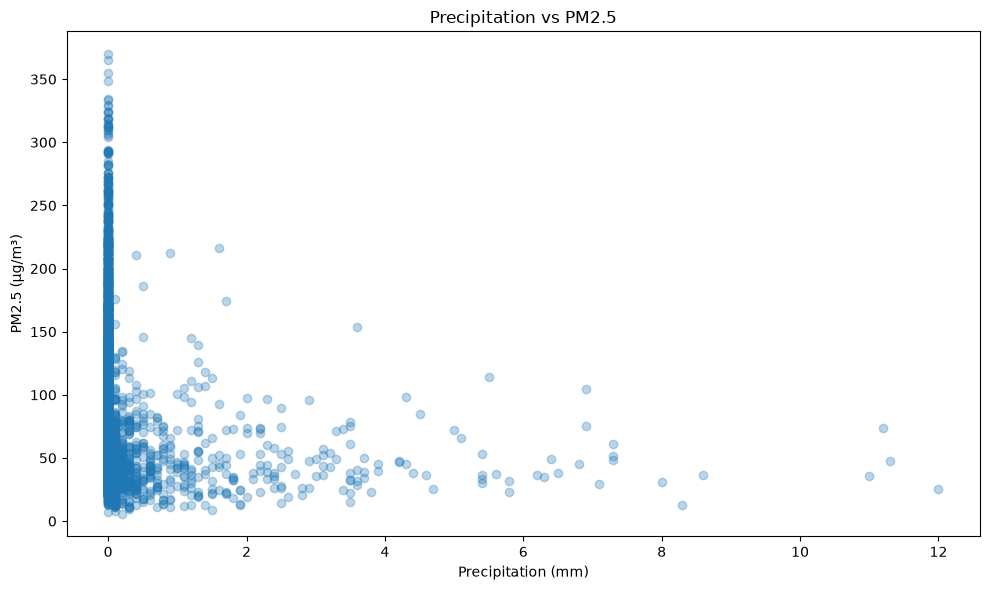

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["precipitation"],
    df["pm2_5"],
    alpha=0.3
)

plt.title("Precipitation vs PM2.5")
plt.xlabel("Precipitation (mm)")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

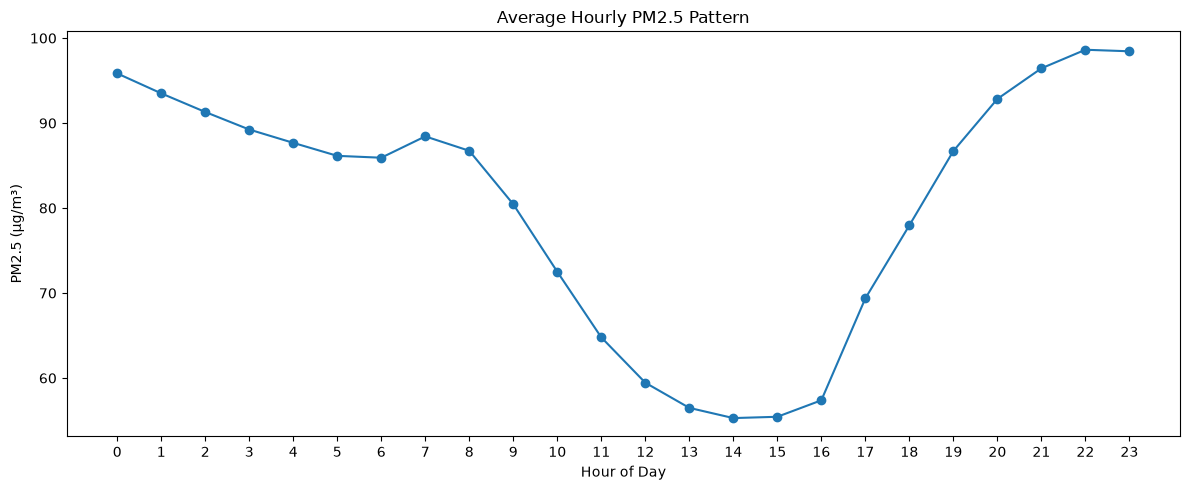

In [17]:
hourly_pm25 = (
    df.groupby("hour")["pm2_5"]
      .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pm25.index,
    hourly_pm25.values,
    marker="o"
)

plt.title("Average Hourly PM2.5 Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [18]:
pm25_threshold = df["pm2_5"].quantile(0.95)
pm10_threshold = df["pm10"].quantile(0.95)

print(
    "PM2.5 95th percentile:",
    round(pm25_threshold, 2)
)

print(
    "PM10 95th percentile:",
    round(pm10_threshold, 2)
)

PM2.5 95th percentile: 172.82
PM10 95th percentile: 571.89


In [19]:
df["extreme_pm25"] = (
    df["pm2_5"] >= pm25_threshold
)

df["extreme_pm10"] = (
    df["pm10"] >= pm10_threshold
)

df["extreme_pollution"] = (
    df["extreme_pm25"] |
    df["extreme_pm10"]
)

In [20]:
print(
    "Extreme PM2.5 observations:",
    df["extreme_pm25"].sum()
)

print(
    "Extreme PM10 observations:",
    df["extreme_pm10"].sum()
)

print(
    "Extreme pollution observations:",
    df["extreme_pollution"].sum()
)

Extreme PM2.5 observations: 438
Extreme PM10 observations: 438
Extreme pollution observations: 866


In [21]:
top_events = (
    df.nlargest(20, "pm2_5")
    [
        [
            "time",
            "pm2_5",
            "pm10",
            "temperature_2m",
            "relative_humidity_2m",
            "wind_speed_10m",
            "precipitation"
        ]
    ]
)

top_events

,time,pm2_5,pm10,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation
214,2025-01-09 22:00:00,369.7,374.4,12.1,82,1.1,0.0
215,2025-01-09 23:00:00,365.1,369.7,11.1,86,2.0,0.0
213,2025-01-09 21:00:00,354.8,356.7,12.6,81,1.9,0.0
216,2025-01-10 00:00:00,348.3,352.0,10.3,90,2.6,0.0
217,2025-01-10 01:00:00,334.3,339.0,9.7,92,2.2,0.0
8350,2025-12-14 22:00:00,333.4,337.1,17.9,69,0.6,0.0
8351,2025-12-14 23:00:00,329.7,334.3,17.4,71,0.2,0.0
8349,2025-12-14 21:00:00,328.8,333.4,18.3,68,1.7,0.0
212,2025-01-09 20:00:00,324.1,326.0,12.9,81,4.1,0.0
218,2025-01-10 02:00:00,324.1,327.8,9.2,93,2.3,0.0


In [23]:
temperature_threshold = (
    df["temperature_2m"].quantile(0.95)
)

print(
    "95th percentile temperature:",
    round(temperature_threshold, 2)
)

df["extreme_heat"] = (
    df["temperature_2m"] >= temperature_threshold
)

95th percentile temperature: 36.4


In [24]:
df["pm25_score"] = (
    df["pm2_5"].rank(pct=True) * 100
)

df["pm10_score"] = (
    df["pm10"].rank(pct=True) * 100
)

df["no2_score"] = (
    df["nitrogen_dioxide"].rank(pct=True) * 100
)

df["so2_score"] = (
    df["sulphur_dioxide"].rank(pct=True) * 100
)

df["o3_score"] = (
    df["ozone"].rank(pct=True) * 100
)

df["co_score"] = (
    df["carbon_monoxide"].rank(pct=True) * 100
)

df["heat_score"] = (
    df["temperature_2m"].rank(pct=True) * 100
)

In [25]:
df["pollution_impact_score"] = (
    0.35 * df["pm25_score"] +
    0.20 * df["pm10_score"] +
    0.15 * df["no2_score"] +
    0.10 * df["o3_score"] +
    0.10 * df["co_score"] +
    0.10 * df["so2_score"]
)

In [26]:
df["climate_environmental_impact"] = (
    0.85 * df["pollution_impact_score"] +
    0.15 * df["heat_score"]
)

In [27]:
def classify_impact(score):
    if score < 20:
        return "Low"
    elif score < 40:
        return "Moderate"
    elif score < 60:
        return "High"
    elif score < 80:
        return "Very High"
    else:
        return "Extreme"


df["impact_category"] = (
    df["climate_environmental_impact"]
    .apply(classify_impact)
)

In [28]:
impact_distribution = (
    df["impact_category"]
    .value_counts()
)

impact_distribution

impact_category
High         3889
Very High    2505
Moderate     2167
Low           168
Extreme        31
Name: count, dtype: int64

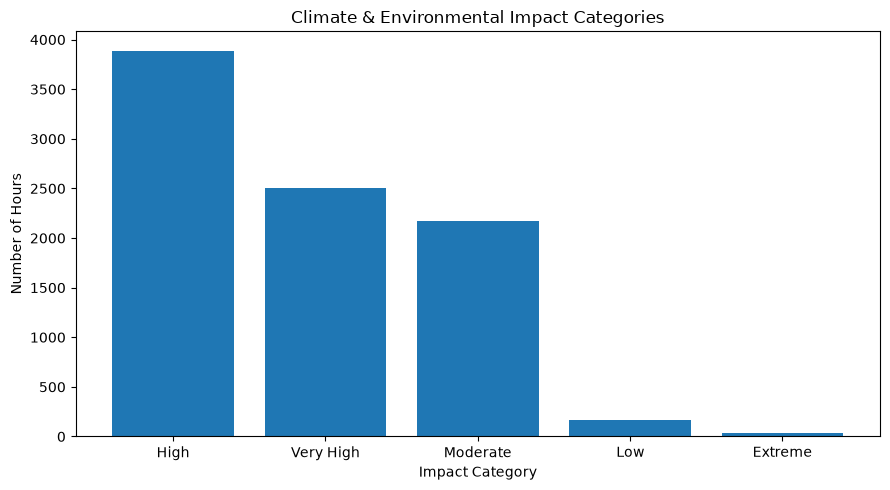

In [29]:
plt.figure(figsize=(9, 5))

plt.bar(
    impact_distribution.index,
    impact_distribution.values
)

plt.title(
    "Climate & Environmental Impact Categories"
)

plt.xlabel("Impact Category")
plt.ylabel("Number of Hours")

plt.tight_layout()
plt.show()

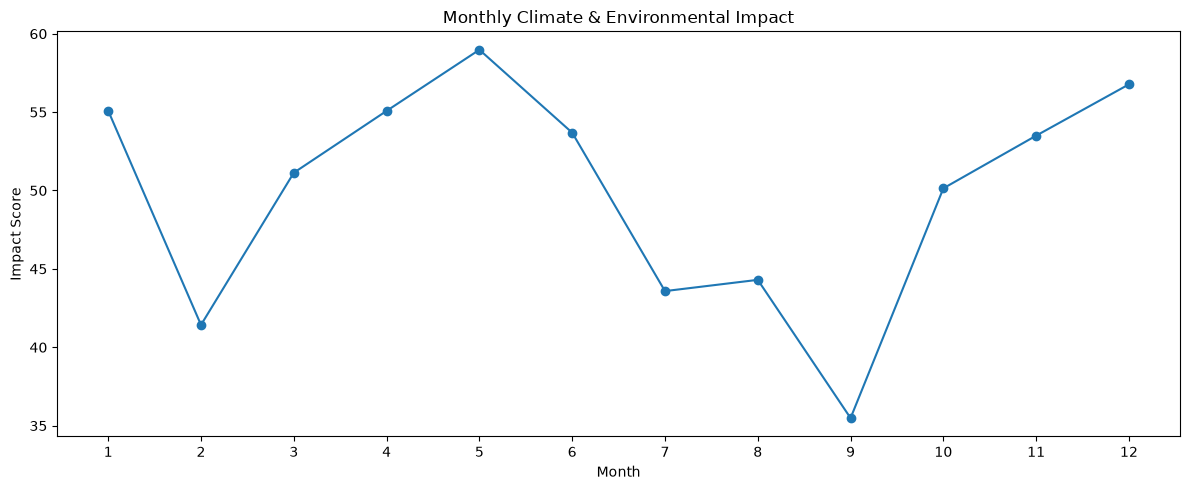

In [30]:
monthly_impact = (
    df.groupby("month")[
        "climate_environmental_impact"
    ]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_impact.index,
    monthly_impact.values,
    marker="o"
)

plt.title(
    "Monthly Climate & Environmental Impact"
)

plt.xlabel("Month")
plt.ylabel("Impact Score")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [31]:
seasonal_impact = (
    df.groupby("season")[
        "climate_environmental_impact"
    ]
    .mean()
    .reindex(season_order)
)

seasonal_impact

season
Winter          51.417564
Summer          55.061884
Monsoon         44.258735
Post-Monsoon    51.790878
Name: climate_environmental_impact, dtype: float64

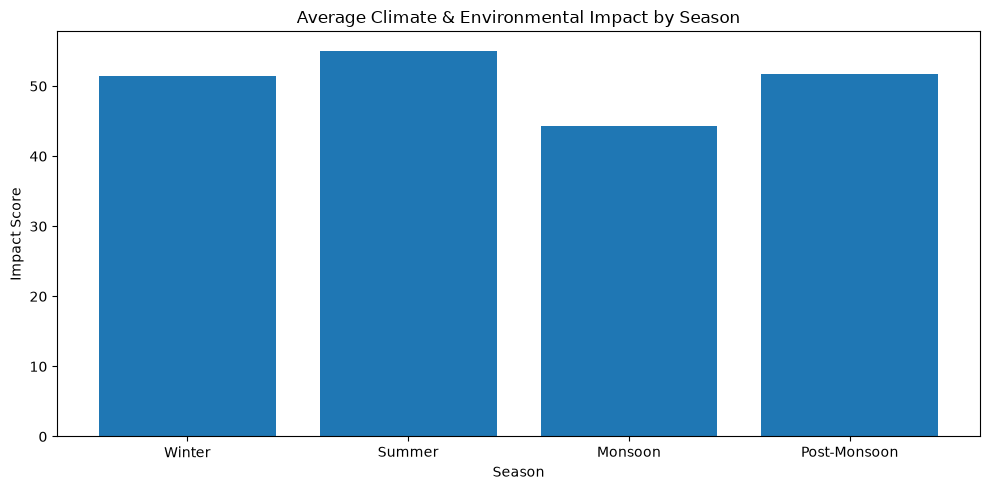

In [32]:
plt.figure(figsize=(10, 5))

plt.bar(
    seasonal_impact.index,
    seasonal_impact.values
)

plt.title(
    "Average Climate & Environmental Impact by Season"
)

plt.xlabel("Season")
plt.ylabel("Impact Score")

plt.tight_layout()
plt.show()

In [33]:
highest_impact = (
    df.nlargest(
        20,
        "climate_environmental_impact"
    )
)

highest_impact[
    [
        "time",
        "pm2_5",
        "pm10",
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "climate_environmental_impact",
        "impact_category"
    ]
]

,time,pm2_5,pm10,temperature_2m,relative_humidity_2m,wind_speed_10m,climate_environmental_impact,impact_category
3608,2025-05-31 08:00:00,159.3,661.2,32.5,53,3.8,85.910031,Extreme
3860,2025-06-10 20:00:00,163.4,1110.1,39.7,19,5.5,85.595220,Extreme
3861,2025-06-10 21:00:00,166.7,1024.5,38.6,22,1.0,85.413328,Extreme
3607,2025-05-31 07:00:00,162.1,542.0,30.3,60,4.7,84.765311,Extreme
4943,2025-07-25 23:00:00,186.3,927.6,31.0,78,1.6,84.291210,Extreme
3862,2025-06-10 22:00:00,160.2,884.8,36.5,26,2.2,83.797032,Extreme
4944,2025-07-26 00:00:00,188.6,916.4,30.5,75,11.7,83.682120,Extreme
4942,2025-07-25 22:00:00,171.4,890.3,31.5,78,0.2,83.602868,Extreme
3609,2025-05-31 09:00:00,152.3,681.7,34.7,42,4.0,83.565953,Extreme
3859,2025-06-10 19:00:00,147.1,1061.7,40.3,19,7.9,82.857249,Extreme


In [34]:
analytics_path = Path(
    "../data/processed/"
    "climate_impact_dataset.csv"
)

df.to_csv(
    analytics_path,
    index=False
)

print(
    f"Analytics dataset saved to: {analytics_path}"
)

Analytics dataset saved to: ..\data\processed\climate_impact_dataset.csv


In [35]:
print("========== CLIMATE IMPACT ANALYTICS ==========")

print("\nDataset shape:")
print(df.shape)

print("\nAverage Impact Score:")
print(
    round(
        df["climate_environmental_impact"].mean(),
        2
    )
)

print("\nMaximum Impact Score:")
print(
    round(
        df["climate_environmental_impact"].max(),
        2
    )
)

print("\nImpact categories:")
print(
    df["impact_category"].value_counts()
)

print("\nExtreme pollution observations:")
print(
    df["extreme_pollution"].sum()
)

========== CLIMATE IMPACT ANALYTICS ==========

Dataset shape:
(8760, 35)

Average Impact Score:
50.01

Maximum Impact Score:
85.91

Impact categories:
impact_category
High         3889
Very High    2505
Moderate     2167
Low           168
Extreme        31
Name: count, dtype: int64

Extreme pollution observations:
866


## Key Findings

- The integrated environmental dataset contains 8,760 hourly observations covering Delhi for the complete year 2025.

- The Climate & Environmental Impact Index has an average score of approximately 50.01, indicating substantial variation in environmental conditions throughout the year.

- The highest average seasonal impact score was observed during Summer (55.06), followed by Post-Monsoon (51.79), Winter (51.42), and Monsoon (44.26).

- Monsoon recorded the lowest average Climate & Environmental Impact Score, suggesting comparatively lower combined environmental stress during this period.

- The analysis identified 866 hourly observations as extreme pollution events based on the 95th-percentile thresholds for PM2.5 and PM10.

- The impact classification produced 3,889 High-impact hours, 2,505 Very High-impact hours, 2,167 Moderate-impact hours, 168 Low-impact hours, and 31 Extreme-impact hours.

- Several high-impact periods were associated with simultaneously elevated particulate pollution and high temperatures. For example, the analysis identified an event on June 10, 2025, when PM2.5 reached 163.4 µg/m³, PM10 reached 1,110.1 µg/m³, and temperature reached 39.7°C.

- Earlier air-quality analysis showed that PM2.5 was highest during January and December, while September had the lowest monthly PM2.5 average. PM10 showed particularly high monthly averages during March–May.

- The analysis demonstrates that environmental impact cannot be represented by a single pollutant or weather variable. Combining multiple pollutant indicators with temperature provides a broader representation of environmental stress.

### Methodological Note

The Climate & Environmental Impact Index is a project-specific analytical composite indicator created for comparative analysis and dashboard visualization. It is not an official Air Quality Index (AQI), medical risk score, or government classification.

The index uses percentile-based normalization so that pollutants with different units and numerical ranges can be combined on a common 0–100 scale.